# Part 4: Five-Day VaR, ES and Backtesting

Value at Risk (VaR) is a loss threshold associated with a chosen confidence level.
Expected Shortfall (ES) is the average loss beyond that threshold under the assumed model.
We compare Historical Volatility, EWMA, and the ML model chosen on validation data.
Every input forecast is genuinely out of sample from Part 3.

We assume a zero conditional daily mean and conditionally independent normal daily
returns with constant variance over the next five sessions. With annualized sigma,
the five-day standard deviation is sigma * sqrt(5/252), not sigma or sigma * sqrt(5).
Positive loss VaR = z[c] * sigma_5; ES = sigma_5 * phi(z[c]) / (1-c).
The lower return threshold is -VaR. A violation occurs if the realised return is below it.

Realised returns are compounded exactly: product(1+r[t+1:t+5])-1.
The normal VaR uses the arithmetic-sum approximation to this compound return.
This approximation, zero drift, heavy tails, serial dependence and forecast uncertainty
can all affect coverage. ES is reported, but Kupiec tests VaR frequency, not ES accuracy.

In [1]:
from pathlib import Path
import json
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import norm, chi2, binom, binomtest
from scipy.special import xlogy
from scipy.integrate import quad

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir() and (p / 'data').is_dir())
TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables'
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures'
predictions = pd.read_csv(TABLE_DIR / 'test_predictions.csv', index_col='Date', parse_dates=['Date', 'target_start', 'target_end'])
selection = json.loads((TABLE_DIR / 'model_selection.json').read_text())
quality3 = json.loads((TABLE_DIR / 'part3_quality_report.json').read_text())
assert hashlib.sha256((TABLE_DIR / 'test_predictions.csv').read_bytes()).hexdigest() == quality3['test_predictions_sha256']
models = ['Historical Volatility', 'EWMA', selection['selected_ml_model']]
daily = pd.read_csv(PROJECT_ROOT / 'data/processed/portfolio_daily_returns.csv', index_col='Date', parse_dates=True).portfolio_return
assert predictions.index.is_unique and predictions.index.is_monotonic_increasing
assert predictions.index.min() >= pd.Timestamp(selection['test_start'])

## Align future returns with forecasts

A forecast made at the close of t is evaluated against returns from t+1 through t+5.
We save these start/end dates explicitly. They are outcomes only, never model features.
The independent check compounds each five-day slice directly and verifies every date.

In [2]:
future = pd.concat([daily.shift(-step) for step in range(1, 6)], axis=1)
actual_five_day_return = ((1 + future).prod(axis=1) - 1).where(future.notna().all(axis=1))
actual = actual_five_day_return.loc[predictions.index]
for date in predictions.index:
    position = daily.index.get_loc(date)
    window = daily.iloc[position+1:position+6]
    assert len(window) == 5
    assert window.index[0] == predictions.loc[date, 'target_start']
    assert window.index[-1] == predictions.loc[date, 'target_end']
    np.testing.assert_allclose(actual.loc[date], np.expm1(np.log1p(window).sum()), atol=1e-14)
    np.testing.assert_allclose(predictions.loc[date, 'actual_volatility'], window.std(ddof=1)*np.sqrt(252), atol=1e-12)

risk_frames = []
for model in models:
    sigma_five_day = predictions[model] * np.sqrt(5 / 252)
    for confidence in [0.95, 0.99]:
        quantile = norm.ppf(confidence)
        var = quantile * sigma_five_day
        es = norm.pdf(quantile) * sigma_five_day / (1-confidence)
        frame = pd.DataFrame({'model': model, 'confidence': confidence,
                              'target_start': predictions.target_start, 'target_end': predictions.target_end,
                              'annualized_volatility': predictions[model], 'sigma_5d': sigma_five_day,
                              'actual_return_5d': actual, 'VaR_loss': var, 'ES_loss': es,
                              'return_threshold': -var, 'violation': actual < -var})
        assert np.isfinite(frame.select_dtypes(include='number').to_numpy()).all()
        assert (frame.VaR_loss > 0).all() and (frame.ES_loss > frame.VaR_loss).all()
        # Independent lower-tail quantile and sign checks.
        np.testing.assert_allclose(frame.return_threshold, norm.ppf(1-confidence, loc=0, scale=sigma_five_day), atol=1e-12)
        np.testing.assert_array_equal(frame.violation, -frame.actual_return_5d > frame.VaR_loss)
        # Numerical lower-tail integration independently checks the ES formula.
        integrated_tail, _ = quad(lambda z: -z * norm.pdf(z), -np.inf, norm.ppf(1-confidence))
        np.testing.assert_allclose(frame.ES_loss / sigma_five_day, integrated_tail / (1-confidence), rtol=1e-10)
        risk_frames.append(frame.reset_index(names='Date'))
risk = pd.concat(risk_frames, ignore_index=True)
for model in models:
    low = risk.loc[(risk.model == model) & (risk.confidence == 0.95)].set_index('Date')
    high = risk.loc[(risk.model == model) & (risk.confidence == 0.99)].set_index('Date')
    assert (high.VaR_loss > low.VaR_loss).all()
    assert (high.ES_loss > low.ES_loss).all()
    assert not (high.violation & ~low.violation).any()
risk.to_csv(TABLE_DIR / 'risk_forecasts.csv', index=False)
print('All five-day return alignment, volatility-unit, confidence and violation-sign checks passed.')

All five-day return alignment, volatility-unit, confidence and violation-sign checks passed.


## Backtesting without overlapping outcome windows

Backtesting compares past forecasts with the outcomes that followed them. A 95% VaR
ideally has a 5% violation probability; a 99% VaR has a 1% probability.
Kupiec's unconditional coverage test compares the observed frequency with that expected
probability using a likelihood ratio with an asymptotic chi-square(1) reference.
A small p-value indicates evidence against correct unconditional coverage. A large
p-value does not prove the model is correct or that violations are independent.

The main test takes every fifth forecast starting with the first test date, so its
five-return outcome windows do not overlap. This anchor is fixed before seeing violations.
Daily overlapping counts are descriptive only. Residual volatility clustering may remain
even after removing mechanical overlap. The smaller sample has low power, especially at
99%; we also report an exact binomial p-value and an exact 95% interval for the rate.

,model,confidence,observations,violations,violation_rate,expected_rate,expected_violations,kupiec_statistic,kupiec_p_value,exact_binomial_p_value,rate_ci_low,rate_ci_high
0,Historical Volatility,0.95,235,10,0.042553,0.05,11.75,0.288319,0.591300,0.763756,0.020592,0.076863
1,Historical Volatility,0.99,235,3,0.012766,0.01,2.35,0.166999,0.682792,0.511885,0.002640,0.036852
2,EWMA,0.95,235,8,0.034043,0.05,11.75,1.412053,0.234716,0.366086,0.014810,0.065973
3,EWMA,0.99,235,1,0.004255,0.01,2.35,0.998988,0.317556,0.735604,0.000108,0.023480
4,Linear Regression,0.95,235,13,0.055319,0.05,11.75,0.135511,0.712785,0.653063,0.029780,0.092740
5,Linear Regression,0.99,235,4,0.017021,0.01,2.35,0.966762,0.325489,0.304464,0.004657,0.043005


Daily overlapping counts (descriptive, not the Kupiec test sample):


,model,confidence,observations,violations,violation_rate
0,EWMA,0.95,1175,56,0.047660
1,EWMA,0.99,1175,20,0.017021
2,Historical Volatility,0.95,1175,62,0.052766
3,Historical Volatility,0.99,1175,25,0.021277
4,Linear Regression,0.95,1175,76,0.064681
5,Linear Regression,0.99,1175,30,0.025532


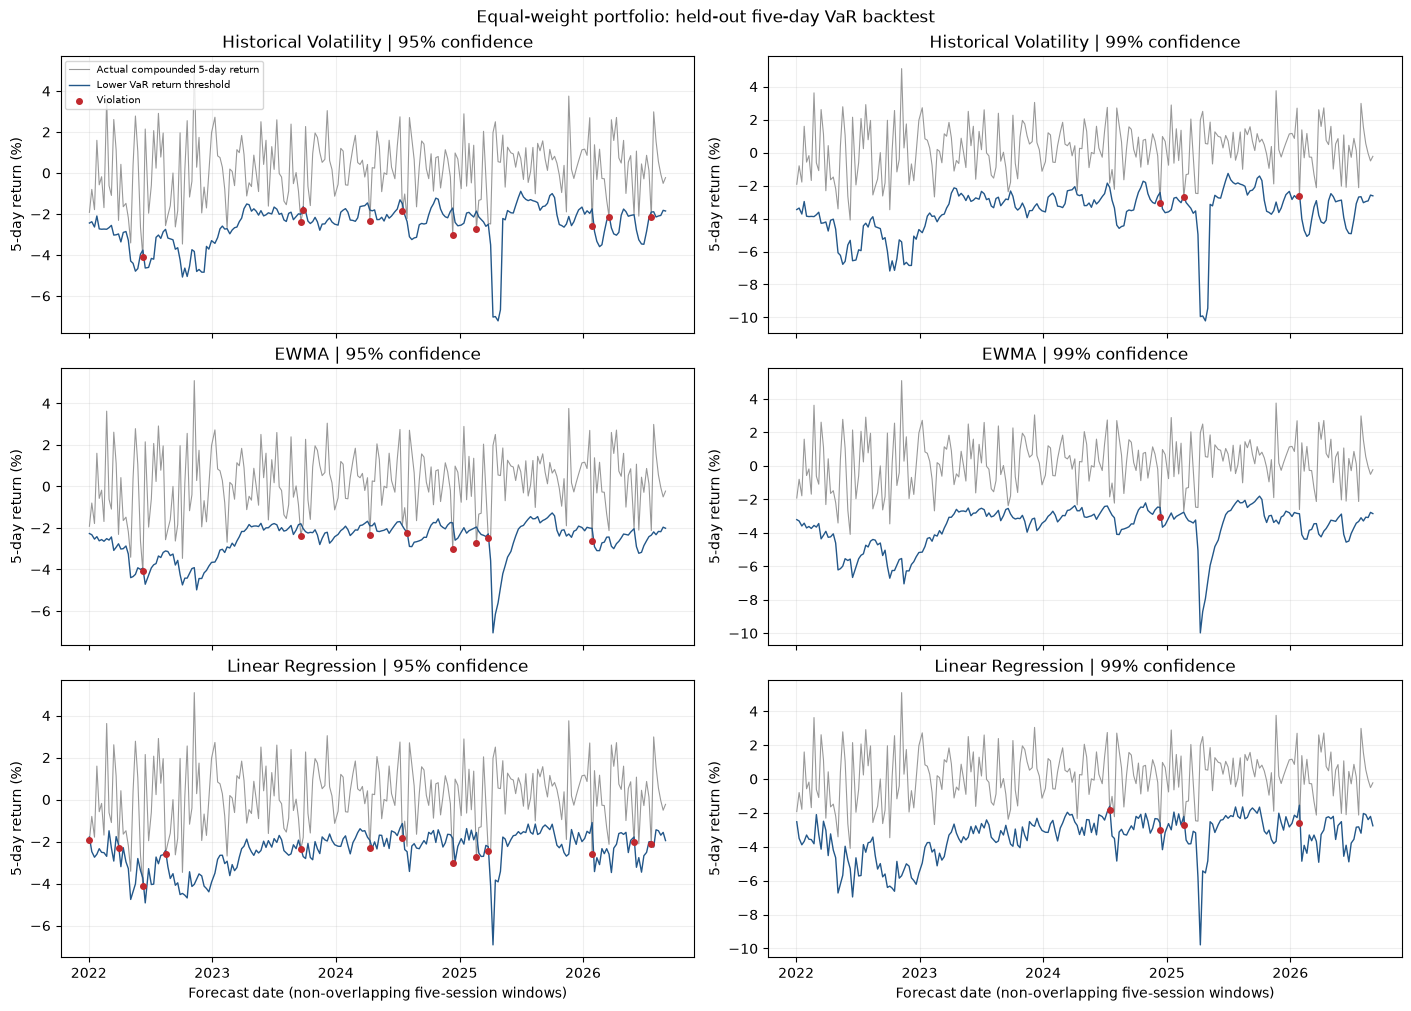

Part 4 completed: risk forecasts, ES, violations and independent coverage checks saved.


In [3]:
def kupiec_test(violations, expected_rate):
    n = len(violations)
    assert n > 0 and 0 < expected_rate < 1
    count = int(np.sum(violations))
    observed_rate = count / n
    null_log_likelihood = xlogy(count, expected_rate) + xlogy(n-count, 1-expected_rate)
    fitted_log_likelihood = xlogy(count, observed_rate) + xlogy(n-count, 1-observed_rate)
    statistic = max(0.0, float(2*(fitted_log_likelihood-null_log_likelihood)))
    return statistic, float(chi2.sf(statistic, df=1))

nonoverlap_dates = predictions.index[::5]
starts = predictions.loc[nonoverlap_dates, 'target_start']
ends = predictions.loc[nonoverlap_dates, 'target_end']
assert np.all(starts.iloc[1:].to_numpy() > ends.iloc[:-1].to_numpy())
nonoverlap = risk.loc[risk.Date.isin(nonoverlap_dates)].copy()
nonoverlap.to_csv(TABLE_DIR / 'nonoverlapping_risk_forecasts.csv', index=False)
backtest_rows = []
for (model, confidence), group in nonoverlap.groupby(['model', 'confidence'], sort=False):
    violations = group.violation.to_numpy()
    n, count = len(group), int(violations.sum())
    expected_rate = 1-confidence
    statistic, p_value = kupiec_test(violations, expected_rate)
    # Independent binomial log-PMF difference; combinatorial terms cancel.
    independent_statistic = 2*(binom.logpmf(count, n, count/n)-binom.logpmf(count, n, expected_rate))
    np.testing.assert_allclose(statistic, independent_statistic, atol=1e-10)
    exact = binomtest(count, n, expected_rate)
    interval = exact.proportion_ci(confidence_level=0.95, method='exact')
    backtest_rows.append(dict(model=model, confidence=confidence, observations=n, violations=count,
                              violation_rate=count/n, expected_rate=expected_rate, expected_violations=n*expected_rate,
                              kupiec_statistic=statistic, kupiec_p_value=p_value, exact_binomial_p_value=exact.pvalue,
                              rate_ci_low=interval.low, rate_ci_high=interval.high))
backtests = pd.DataFrame(backtest_rows)
backtests.to_csv(TABLE_DIR / 'kupiec_backtests.csv', index=False)
descriptive = risk.groupby(['model', 'confidence']).violation.agg(observations='size', violations='sum', violation_rate='mean').reset_index()
descriptive.to_csv(TABLE_DIR / 'overlapping_violation_summary.csv', index=False)
display(backtests)
print('Daily overlapping counts (descriptive, not the Kupiec test sample):')
display(descriptive)

# Edge cases must remain finite when no or all returns violate VaR.
for flags in [np.zeros(100, dtype=bool), np.ones(100, dtype=bool)]:
    statistic, p_value = kupiec_test(flags, 0.05)
    assert np.isfinite(statistic) and 0 <= p_value <= 1
quality = dict(aligned_forecasts=len(predictions), nonoverlapping_windows=len(nonoverlap_dates),
               main_test_anchor=str(nonoverlap_dates[0].date()), outcome_windows_disjoint=True,
               confidence_and_sign_checks=True, all_future_returns_checked=True,
               independent_kupiec_checks=len(backtests), kupiec_edge_cases=2,
               mean_assumption=0, horizon_sessions=5, annualization=252)
(TABLE_DIR / 'part4_quality_report.json').write_text(json.dumps(quality, indent=2))

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True, constrained_layout=True)
for row, model in enumerate(models):
    for col, confidence in enumerate([0.95, 0.99]):
        group = nonoverlap.loc[(nonoverlap.model == model) & (nonoverlap.confidence == confidence)]
        ax = axes[row, col]
        ax.plot(group.Date, group.actual_return_5d*100, color='0.6', lw=0.8, label='Actual compounded 5-day return')
        ax.plot(group.Date, group.return_threshold*100, color='#235789', lw=1, label='Lower VaR return threshold')
        breached = group.loc[group.violation]
        ax.scatter(breached.Date, breached.actual_return_5d*100, color='#c1292e', s=16, zorder=3, label='Violation')
        ax.set_title(f'{model} | {confidence:.0%} confidence')
        ax.set_ylabel('5-day return (%)')
        ax.grid(alpha=0.2)
        if row == 0 and col == 0:
            ax.legend(fontsize=7, loc='upper left')
for ax in axes[-1]:
    ax.set_xlabel('Forecast date (non-overlapping five-session windows)')
fig.suptitle('Equal-weight portfolio: held-out five-day VaR backtest')
fig.savefig(FIGURE_DIR / 'var_violations.png', dpi=160)
if plt.get_backend().lower() != 'agg':
    plt.show()
plt.close(fig)
print('Part 4 completed: risk forecasts, ES, violations and independent coverage checks saved.')